## EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- portable paths --------------------------------------------------------
# Was a hardcoded absolute path to one teammate's machine; resolved from paths.py
# so the notebook runs for everyone. FLAT_POT_CSV is written by 3_Flat_table.ipynb.
import sys
from pathlib import Path
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "paths.py").is_file()), None)
if ROOT is None:
    raise RuntimeError(
        "Cannot find paths.py in any parent of "
        f"{Path.cwd()} — run this notebook from inside the project folder.")
sys.path.insert(0, str(ROOT))
from paths import FLAT_POT_CSV

if not FLAT_POT_CSV.exists():
    raise FileNotFoundError(
        f"{FLAT_POT_CSV} not found — run 3_Flat_table.ipynb first to build it.")

df = pd.read_csv(FLAT_POT_CSV)
df_og = df.copy()
df.shape

(360600, 17)

In [2]:
df.head()

,com_num,name,sector,region,account_type,accounts_overdue,nonlloyds_charges,has_nonlloyds_charge,yrs_since_nonlloyds_chg,n_distinct_lenders,n_charges_last_24m,n_outstanding,n_satisfied,yrs_since_satisfaction,age_years,readmitted,label
0,07852962,369 UPLAND ROAD RTM COMPANY LIMITED,L: Real Estate,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,9.122519,0,0
1,12047798,36A TACHBROOK STREET LIMITED,S: Other Services,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,1.557837,0,0
2,10379693,36ALPHA LTD,J: Information/Comms,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,4.292950,0,0
3,07127657,36DIGITAL LIMITED,J: Information/Comms,East of England,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,10.959617,0,0
4,10812571,36EL LTD,L: Real Estate,London,micro-entity,1,2,1,3.479808,1,0,2,0,50.0,3.564682,0,0


#### Check data types

In [3]:
df.dtypes

com_num                        str
name                           str
sector                         str
region                         str
account_type                   str
accounts_overdue             int64
nonlloyds_charges            int64
has_nonlloyds_charge         int64
yrs_since_nonlloyds_chg    float64
n_distinct_lenders           int64
n_charges_last_24m           int64
n_outstanding                int64
n_satisfied                  int64
yrs_since_satisfaction     float64
age_years                  float64
readmitted                   int64
label                        int64
dtype: object

#### Check missing values

In [4]:
df.isnull().sum()

com_num                    0
name                       0
sector                     0
region                     0
account_type               0
accounts_overdue           0
nonlloyds_charges          0
has_nonlloyds_charge       0
yrs_since_nonlloyds_chg    0
n_distinct_lenders         0
n_charges_last_24m         0
n_outstanding              0
n_satisfied                0
yrs_since_satisfaction     0
age_years                  0
readmitted                 0
label                      0
dtype: int64

#### Check "Label"

In [5]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True)*100)

label
0    359397
1      1203
Name: count, dtype: int64
label
0    99.666389
1     0.333611
Name: proportion, dtype: float64


#### Check unique values

In [6]:
df.nunique()

com_num                    360600
name                       360599
sector                         21
region                         13
account_type                    5
accounts_overdue                2
nonlloyds_charges             111
has_nonlloyds_charge            2
yrs_since_nonlloyds_chg      9008
n_distinct_lenders             35
n_charges_last_24m             40
n_outstanding                  77
n_satisfied                    91
yrs_since_satisfaction       5583
age_years                   15394
readmitted                      1
label                           2
dtype: int64

## CLEANING

In [7]:
df = df.drop(columns=["readmitted"])

In [8]:
print(df.columns)
df.head()

Index(['com_num', 'name', 'sector', 'region', 'account_type',
       'accounts_overdue', 'nonlloyds_charges', 'has_nonlloyds_charge',
       'yrs_since_nonlloyds_chg', 'n_distinct_lenders', 'n_charges_last_24m',
       'n_outstanding', 'n_satisfied', 'yrs_since_satisfaction', 'age_years',
       'label'],
      dtype='str')


,com_num,name,sector,region,account_type,accounts_overdue,nonlloyds_charges,has_nonlloyds_charge,yrs_since_nonlloyds_chg,n_distinct_lenders,n_charges_last_24m,n_outstanding,n_satisfied,yrs_since_satisfaction,age_years,label
0,07852962,369 UPLAND ROAD RTM COMPANY LIMITED,L: Real Estate,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,9.122519,0
1,12047798,36A TACHBROOK STREET LIMITED,S: Other Services,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,1.557837,0
2,10379693,36ALPHA LTD,J: Information/Comms,London,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,4.292950,0
3,07127657,36DIGITAL LIMITED,J: Information/Comms,East of England,micro-entity,0,0,0,50.000000,0,0,0,0,50.0,10.959617,0
4,10812571,36EL LTD,L: Real Estate,London,micro-entity,1,2,1,3.479808,1,0,2,0,50.0,3.564682,0


## MODELLING

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

XGBoost: https://xgboost.readthedocs.io/en/stable/get_started.html# ,  https://xgboost.readthedocs.io/en/stable/parameter.html

Multi-layer Perceptron (MLP): https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html# , https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html

others: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html, https://scikit-learn.org/stable/modules/grid_search.html

In [9]:
df.dtypes

com_num                        str
name                           str
sector                         str
region                         str
account_type                   str
accounts_overdue             int64
nonlloyds_charges            int64
has_nonlloyds_charge         int64
yrs_since_nonlloyds_chg    float64
n_distinct_lenders           int64
n_charges_last_24m           int64
n_outstanding                int64
n_satisfied                  int64
yrs_since_satisfaction     float64
age_years                  float64
label                        int64
dtype: object

In [10]:
iden_cols = ["com_num", "name"]
cat_cols = ["sector", "region", "account_type"]
bool_cols = ["accounts_overdue", "has_nonlloyds_charge"]
num_cols = ["nonlloyds_charges", "yrs_since_nonlloyds_chg", 
            "n_distinct_lenders", "n_charges_last_24m", "n_outstanding",
            "n_satisfied", "yrs_since_satisfaction", "age_years"]
target_col = "label"

feature_cols = cat_cols + bool_cols + num_cols
feature_cols

['sector',
 'region',
 'account_type',
 'accounts_overdue',
 'has_nonlloyds_charge',
 'nonlloyds_charges',
 'yrs_since_nonlloyds_chg',
 'n_distinct_lenders',
 'n_charges_last_24m',
 'n_outstanding',
 'n_satisfied',
 'yrs_since_satisfaction',
 'age_years']

In [11]:
from sklearn.model_selection import train_test_split

RS = 42

X = df[feature_cols]
y = df[target_col]
iden = df[iden_cols]

X_train, X_test, y_train, y_test, iden_train, iden_test = train_test_split(
    X, y, iden, test_size=0.2, random_state=RS, stratify=y)

In [12]:
print(y_train.sum())
print(y_test.sum())

962
241


### Pipeline

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

RS = 42

# Preprocess
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
], remainder="passthrough")

# Logistic Regression
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RS
)

pipe_lr = Pipeline([
    ("prep_lr", preprocess),
    ("clf_lr", model_lr)
])

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # sum(negative instances) / sum(positive instances)
print(f"scale_pos_weight: {scale_pos_weight}")

model_xgb = XGBClassifier(
    n_estimators=100, # default
    max_depth=6, # default
    learning_rate=0.3, # default
    scale_pos_weight=scale_pos_weight,
    random_state=RS
)

pipe_xgb = Pipeline([
    ("prep_xgb", preprocess),
    ("clf_xgb", model_xgb)
])

# MLP
model_nn = MLPClassifier(
    hidden_layer_sizes=(100, ), # default
    activation="relu", # default
    alpha=0.0001, # default
    learning_rate_init=0.001, # default
    max_iter=200, # default
    early_stopping=True, # default = False
    random_state=RS
)

pipe_nn = Pipeline([
    ("prep_nn", preprocess),
    ("clf_nn", model_nn)
])

scale_pos_weight: 298.87525987525987


### Cross-validation/Grid Search

In [14]:
# 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

#### Logistic Regression

In [15]:
# Default: C = 1
param_grid_lr = {"clf_lr__C": [0.01, 0.1, 1, 10]} # try 5 different C values

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring="average_precision")
grid_lr.fit(X_train, y_train)

# print(grid_lr.cv_results_)
results_lr = pd.DataFrame(grid_lr.cv_results_)
print(results_lr[["params","mean_test_score"]].sort_values("mean_test_score", ascending=False))


                params  mean_test_score
1   {'clf_lr__C': 0.1}         0.010115
0  {'clf_lr__C': 0.01}         0.010114
3    {'clf_lr__C': 10}         0.010112
2     {'clf_lr__C': 1}         0.010109


Best Config: {'clf_lr__C': 0.1} with AP = 0.010115 (barely better than others)

#### XGBoost

In [16]:
# Default: n_estimators = 100, max_depth = 6, learning_rate = 0.3

param_grid_xgb = {"clf_xgb__n_estimators": [50, 100, 200],
                  "clf_xgb__max_depth": [4, 6, 8],
                  "clf_xgb__learning_rate": [0.001, 0.01, 0.1, 0.3]}

grid_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, cv=cv, scoring="average_precision")
grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
results_xgb = pd.DataFrame(grid_xgb.cv_results_)
print(results_xgb[["params","mean_test_score"]].sort_values("mean_test_score", ascending=False).to_string())


{'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 6, 'clf_xgb__n_estimators': 200}
                                                                                      params  mean_test_score
14   {'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 6, 'clf_xgb__n_estimators': 200}         0.011957
18     {'clf_xgb__learning_rate': 0.1, 'clf_xgb__max_depth': 4, 'clf_xgb__n_estimators': 50}         0.011713
11   {'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 4, 'clf_xgb__n_estimators': 200}         0.011699
13   {'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 6, 'clf_xgb__n_estimators': 100}         0.011134
16   {'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 8, 'clf_xgb__n_estimators': 100}         0.011126
21     {'clf_xgb__learning_rate': 0.1, 'clf_xgb__max_depth': 6, 'clf_xgb__n_estimators': 50}         0.010990
19    {'clf_xgb__learning_rate': 0.1, 'clf_xgb__max_depth': 4, 'clf_xgb__n_estimators': 100}         0.010811
22    {'clf_xgb__learning_rate':

Best Config: {'clf_xgb__learning_rate': 0.01, 'clf_xgb__max_depth': 6, 'clf_xgb__n_estimators': 200} with AP = 0.011957

#### MLP

In [17]:
# MLPClassifier has no class_weight parameter, so the imbalance has to be handled
# with per-sample weights at fit time. Without this the net minimises overall error by
# predicting the majority class everywhere -- which is why it returned no positives at
# threshold 0.5. Needs scikit-learn >= 1.8 (sample_weight was added to MLPClassifier.fit).
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
sample_weight = np.where(
    y_train == 1,
    weight_ratio,
    1.0
)

# Default: hidden_layer_sizes = (100, ), alpha = 0.0001
# learning_rate_init = 0.001, max_iter = 200

param_grid_nn = {"clf_nn__alpha": [0.00001, 0.0001, 0.001],
                  "clf_nn__learning_rate_init": [0.0001, 0.001, 0.01],
                  "clf_nn__max_iter": [100, 200, 300]}

grid_nn = GridSearchCV(pipe_nn, param_grid_nn, cv=cv, scoring="average_precision")
grid_nn.fit(X_train, y_train, clf_nn__sample_weight=sample_weight)

print(grid_nn.best_params_)
results_nn = pd.DataFrame(grid_nn.cv_results_)
print(results_nn[["params","mean_test_score"]].sort_values("mean_test_score", ascending=False).to_string())


{'clf_nn__alpha': 1e-05, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 100}
                                                                                      params  mean_test_score
0    {'clf_nn__alpha': 1e-05, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 100}         0.010506
2    {'clf_nn__alpha': 1e-05, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 300}         0.010506
1    {'clf_nn__alpha': 1e-05, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 200}         0.010506
11  {'clf_nn__alpha': 0.0001, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 300}         0.010426
9   {'clf_nn__alpha': 0.0001, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 100}         0.010426
10  {'clf_nn__alpha': 0.0001, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 200}         0.010426
20   {'clf_nn__alpha': 0.001, 'clf_nn__learning_rate_init': 0.0001, 'clf_nn__max_iter': 300}         0.010338
19   {'clf_nn__alpha': 0.001, 'c

In [18]:
pipe_lr = grid_lr.best_estimator_
pipe_xgb = grid_xgb.best_estimator_
pipe_nn = grid_nn.best_estimator_

In [19]:
# pipe_lr

In [20]:
# pipe_xgb

In [21]:
# pipe_nn

## Model Assessment

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [22]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve

y_pred_lr = pipe_lr.predict(X_test)
y_pred_xgb = pipe_xgb.predict(X_test)
y_pred_nn = pipe_nn.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))
print("\nXGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))
print("\nMLP")
print(classification_report(y_test, y_pred_nn, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

Logistic Regression
                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.67      0.80     71879
    Lloyds Customer       0.01      0.71      0.01       241

           accuracy                           0.67     72120
          macro avg       0.50      0.69      0.41     72120
       weighted avg       1.00      0.67      0.80     72120


XGBoost
                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.64      0.78     71879
    Lloyds Customer       0.01      0.75      0.01       241

           accuracy                           0.64     72120
          macro avg       0.50      0.69      0.40     72120
       weighted avg       1.00      0.64      0.78     72120


MLP
                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.86      0.92     71879
    Lloyds Customer       0.01      0.41      0.02       241

           accuracy                        

### Confusion Matrix

In [23]:
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print("\nXGBoost")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nMLP")
print(confusion_matrix(y_test, y_pred_nn))

Logistic Regression
[[47892 23987]
 [   71   170]]

XGBoost
[[45905 25974]
 [   61   180]]

MLP
[[61965  9914]
 [  142    99]]


### Comparision: ROC-AUC, AP, Precision@K

In [24]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
y_proba_nn = pipe_nn.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
auc_nn = roc_auc_score(y_test, y_proba_nn)

ap_lr = average_precision_score(y_test, y_proba_lr)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
ap_nn = average_precision_score(y_test, y_proba_nn)

In [25]:
def precision_at_k(y_test, y_proba, k):
    results = pd.DataFrame({
        "y_true": y_test,
        "y_score": y_proba
    })
    top_k = results.sort_values("y_score", ascending=False).head(k) # Sort by predicted score, descending
    precision = top_k["y_true"].sum() / k
    return precision

In [26]:
models_proba = {
    "Logistic Regression": y_proba_lr,
    "XGBoost": y_proba_xgb,
    "Neural Network (MLP)": y_proba_nn
}

models_auc = {
    "Logistic Regression": auc_lr,
    "XGBoost": auc_xgb,
    "Neural Network (MLP)": auc_nn
}

models_ap = {
    "Logistic Regression": ap_lr,
    "XGBoost": ap_xgb,
    "Neural Network (MLP)": ap_nn
}

rows = []
for name, proba in models_proba.items():
    row = {
        "Model": name,
        "ROC-AUC": models_auc[name],
        "AP": models_ap[name]
    }
    for k in [100, 200, 500, 1000]:
        row[f"Precision@{k}"] = precision_at_k(y_test, proba, k)
    rows.append(row)

# rows
comparision = pd.DataFrame(rows)
comparision

,Model,ROC-AUC,AP,Precision@100,Precision@200,Precision@500,Precision@1000
0,Logistic Regression,0.753619,0.010040,0.03,0.030,0.030,0.019
1,XGBoost,0.757248,0.009873,0.02,0.025,0.016,0.018
2,Neural Network (MLP),0.762443,0.010987,0.05,0.030,0.016,0.017


### Top n Companies

In [27]:
def top_n(y_test, y_proba, n):
    results = iden_test.assign(
        y_true=y_test,
        y_score=y_proba
    )
    return results.sort_values("y_score", ascending=False).head(n)

#### Top n companies - Logistic Regression

In [28]:
top10_lr = top_n(y_test, y_proba_lr, 10)
top10_lr

,com_num,name,y_true,y_score
333389,01209913,PASENGUARD LIMITED,0,0.997388
293861,07434157,LAST SECONDS (UK) LIMITED,0,0.986600
142161,10230909,ASSURED HEALTHCARE SOLUTIONS LTD,0,0.980355
355995,09090171,ROTHERWOOD HEALTHCARE (ST GEORGES PARK) LIMITED,0,0.979878
278384,03863548,J SAI COUNTRY HOME LIMITED,0,0.978485
133991,08034100,ASCOT CARE (ST ANNE'S) LTD,0,0.977674
51843,09729306,ADL LIVERPOOL LIMITED,0,0.974975
325160,06267792,NOUVITA LIMITED,0,0.974769
115889,10516406,APPLEGARTH HEALTHCARE LIMITED,0,0.974377
341147,04126483,PREMIER HOUSING (BRADFORD) LTD,0,0.973589


#### Top n companies - XGBoost

In [29]:
top10_xgb = top_n(y_test, y_proba_xgb, 10)
top10_xgb

,com_num,name,y_true,y_score
336096,SC340956,PERTH HOMECARE SERVICES LTD,0,0.873482
219427,SC368324,CRANNOCH RESIDENTIAL CHILD CARE RESOURCE LTD,0,0.873482
201043,07231974,BTI BIOTECHNOLOGY UK LTD,0,0.872894
119999,07375934,ARANDAL PROPERTIES LIMITED,0,0.872894
63398,06779491,AHEAD4BABIES LIMITED,0,0.872894
288207,07038499,KENVER HOUSE LTD,0,0.872894
42974,07949513,ACHIEVERS DAY NURSERY LTD,0,0.872894
10315,07869347,740 (JC) LIMITED,0,0.872894
10316,07869338,740 (RH) LIMITED,0,0.872894
114783,07099027,APOLLO DENTAL HEALTH CLINIC LIMITED,0,0.872247


#### Top n companies - MLP

In [30]:
top10_nn = top_n(y_test, y_proba_nn, 10)
top10_nn

,com_num,name,y_true,y_score
145806,03356768,ATKIN DEVELOPMENTS LIMITED,0,0.885622
293861,07434157,LAST SECONDS (UK) LIMITED,0,0.880485
229154,03947556,DIRECTFIELD LIMITED,0,0.876022
244702,08201419,FELLSIDE PROPERTY RENTALS LIMITED,0,0.873017
341935,05104042,PRIMECO LIMITED,0,0.860329
262535,10800654,HAMPTON (MIDLAND CARE) LTD,0,0.858572
98484,10723591,AMS CARE SERVICES LTD,0,0.858208
211344,05282808,CHURCH PROPERTY HOLDINGS LIMITED,0,0.855549
348025,09597620,RANA INDUSTRIES LIMITED,1,0.852747
239867,05909506,EQUFUND (SPV1) LIMITED,0,0.851073


### Coefficient / Feature Importance

https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

https://stackoverflow.com/questions/58615904/how-to-extract-coefficients-from-fitted-pipeline-for-penalized-logistic-regressi

### Logistic Regression - Coefficient

In [31]:
features_lr = pipe_lr.named_steps["prep_lr"].get_feature_names_out()
coef_lr = pipe_lr.named_steps["clf_lr"].coef_[0]

coef_df = pd.DataFrame({
    "feature": features_lr,
    "coefficient": coef_lr
})
coef_df.sort_values("coefficient", ascending=False)

,feature,coefficient
34,cat__account_type_medium,1.423265
16,cat__sector_Q: Health/Social,1.277187
36,cat__account_type_small,0.782319
24,cat__region_North East,0.743229
33,cat__region_unknown,0.730580
27,cat__region_Scotland,0.637594
0,cat__sector_A: Agriculture,0.622467
6,cat__sector_G: Retail/Wholesale,0.498944
4,cat__sector_E: Water/Waste,0.478770
11,cat__sector_L: Real Estate,0.413108


### XGBoost

#### Feature Importance

https://xgboost.readthedocs.io/en/stable/python/python_api.html

In [32]:
features_xgb = pipe_xgb.named_steps["prep_xgb"].get_feature_names_out()
fea_importance = pipe_xgb.named_steps["clf_xgb"].feature_importances_

fea_importance_df = pd.DataFrame({
    "feature": features_xgb,
    "importance": fea_importance
})
fea_importance_df.sort_values("importance", ascending=False)

,feature,importance
35,cat__account_type_micro-entity,0.425852
11,cat__sector_L: Real Estate,0.048498
40,num__yrs_since_nonlloyds_chg,0.034578
9,cat__sector_J: Information/Comms,0.032855
16,cat__sector_Q: Health/Social,0.029273
12,cat__sector_M: Professional/Scientific,0.021844
8,cat__sector_I: Accommodation/Food,0.020203
17,cat__sector_R: Arts/Recreation,0.019340
6,cat__sector_G: Retail/Wholesale,0.017627
24,cat__region_North East,0.017579


#### SHAP

https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Basic%20SHAP%20Interaction%20Value%20Example%20in%20XGBoost.html

https://shap.readthedocs.io/en/latest/generated/shap.Explanation.html

In [33]:
# !pip install shap

In [34]:
import shap

X_test_preprocessed = pipe_xgb.named_steps["prep_xgb"].transform(X_test)
pred = pipe_xgb.named_steps["clf_xgb"].predict(X_test_preprocessed, output_margin=True)

explainer = shap.TreeExplainer(pipe_xgb.named_steps["clf_xgb"])
explanation = explainer(X_test_preprocessed)
explanation.feature_names = features_xgb

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


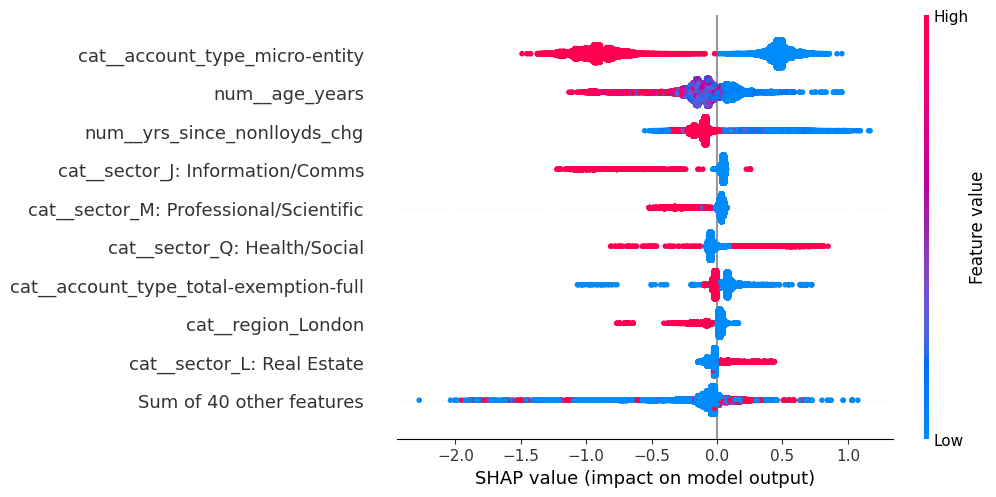

In [35]:
shap.plots.beeswarm(explanation)

## Ship it — refit on all rows and save the artifact

Everything above is *evaluation*: the 80/20 split exists so the reported metrics come from
rows the model never saw. That split has done its job by this point.

The model you hand over should be refit on **all** rows. Holding back 20% of an already
scarce 1,203 positives buys nothing once the evaluation is finished — those 241 positives
are real signal the shipped model may as well learn from.

`clone()` makes an unfitted copy, so the evaluated objects above are left untouched and every
number printed earlier stays valid. XGBoost's `scale_pos_weight` is recomputed on the full
data, since its old value was derived from `y_train` alone, and the MLP's `sample_weight`
is rebuilt on the full `y` for the same reason.

The manifest is what makes a score defensible six months from now: it records which model,
which features in which order, and which data file produced it. `5_score.ipynb` reads the
artifact and checks its feature list against the columns it built.

In [36]:
# --- Refit on ALL rows and save the artifact 5_score.ipynb will load -------------
import json, hashlib, datetime as _dt
import joblib, sklearn
from sklearn.base import clone

# Which model to ship. LogReg is the project's primary (explainable, and the
# coefficients are what justify the lead list to an RM); the others are comparators.
SHIP = "logreg"                      # "logreg" | "xgboost" | "mlp"

# looked up by NAME so an uninstalled comparator (e.g. xgboost) can't break this
# cell when it isn't the model being shipped.
_CHOICES = {"logreg": "pipe_lr", "xgboost": "pipe_xgb", "mlp": "pipe_nn"}
if _CHOICES[SHIP] not in globals():
    raise NameError(f"{_CHOICES[SHIP]} is not defined -- run the {SHIP} cells above first")
model = clone(globals()[_CHOICES[SHIP]])   # unfitted copy -> nothing above is disturbed

# XGBoost's imbalance weight was computed from y_train; recompute it on all rows.
if SHIP == "xgboost":
    model.set_params(clf_xgb__scale_pos_weight=(y == 0).sum() / (y == 1).sum())

# MLP has no class_weight parameter -- its imbalance handling is the sample_weight
# passed at fit time, so the refit has to carry it too. Without this the shipped MLP
# would be trained differently from the one evaluated above.
fit_kw = {}
if SHIP == "mlp":
    fit_kw["clf_nn__sample_weight"] = np.where(
        y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

model.fit(X, y, **fit_kw)            # ALL rows, not X_train
print(f"refit {SHIP} on {len(X):,} rows / {int(y.sum()):,} positives "
      f"(evaluation used {len(X_train):,} / {int(y_train.sum()):,})")

from paths import MODEL_DIR              # single source of truth for locations
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_FILE = MODEL_DIR / "model.joblib"
joblib.dump(model, MODEL_FILE)

# The manifest: what a score can be traced back to.
manifest = {
    "model":            SHIP,
    "trained_at":       _dt.datetime.now().isoformat(timespec="seconds"),
    "trained_on_rows":  int(len(X)),
    "trained_on_positives": int(y.sum()),
    "prevalence":       round(float(y.mean()), 6),
    "source_table":     str(FLAT_POT_CSV),
    "source_sha256":    hashlib.sha256(FLAT_POT_CSV.read_bytes()).hexdigest()[:16],
    # feature ORDER matters -- 5_score.ipynb rebuilds columns to match this exactly
    "feature_cols":     list(feature_cols),
    "cat_cols":         list(cat_cols),
    "num_cols":         list(num_cols),
    "sklearn_version":  sklearn.__version__,
}
(MODEL_DIR / "model_manifest.json").write_text(json.dumps(manifest, indent=2))

print(f"saved -> {MODEL_FILE}")
print(f"saved -> {MODEL_DIR / 'model_manifest.json'}")
print(json.dumps({k: v for k, v in manifest.items() if k != "feature_cols"}, indent=2))


refit logreg on 360,600 rows / 1,203 positives (evaluation used 288,480 / 962)
saved -> /Users/natchalin_/Projects/final_project/Lloyds/Model/model.joblib
saved -> /Users/natchalin_/Projects/final_project/Lloyds/Model/model_manifest.json
{
  "model": "logreg",
  "trained_at": "2026-09-03T19:57:25",
  "trained_on_rows": 360600,
  "trained_on_positives": 1203,
  "prevalence": 0.003336,
  "source_table": "/Users/natchalin_/Projects/final_project/Lloyds/API/flat_pot.csv",
  "source_sha256": "9c1daa03ba2e745b",
  "cat_cols": [
    "sector",
    "region",
    "account_type"
  ],
  "num_cols": [
    "nonlloyds_charges",
    "yrs_since_nonlloyds_chg",
    "n_distinct_lenders",
    "n_charges_last_24m",
    "n_outstanding",
    "n_satisfied",
    "yrs_since_satisfaction",
    "age_years"
  ],
  "sklearn_version": "1.8.0"
}
